# Прогнозирование спроса на велосипеды для BikeSouth

## Описание исследования

Компания **BikeSouth** развивает городской велопрокат на юге России и хочет улучшить прогнозирование почасового спроса на велосипеды. Ранее использовалась линейная регрессия, но она недостаточно гибко учитывала погодный контекст: одинаковая температура при сухой солнечной погоде и после дождя может давать разный спрос.

В проекте я проверю предоставленную baseline-модель и обучу две нелинейные модели: **kNN Regressor** и **Decision Tree Regressor**. Подбор гиперпараметров будет выполнен с помощью **Optuna**.

---

## Цель исследования

Разработать модель, которая точнее baseline-модели предсказывает количество велосипедов, арендованных за конкретный час.

---

## Задачи исследования

1. Загрузить данные и привести названия столбцов к удобному формату.
2. Проверить предоставленный baseline-пайплайн с линейной регрессией.
3. Провести первичный анализ данных: типы, пропуски, уникальные значения.
4. Изучить распределение целевой переменной и связь спроса с погодными, сезонными и временными признаками.
5. Реализовать кастомный трансформер для создания дополнительных признаков.
6. Обучить kNN и дерево решений, подобрать гиперпараметры через Optuna.
7. Сравнить модели по RMSE, MAE и R² на единой 5-fold кросс-валидации.
8. Один раз проверить лучшую модель на тестовой выборке и сравнить её с baseline.
9. Оценить важность признаков и сформулировать рекомендации для BikeSouth.

---

## Исходные данные

| Файл | Описание |
| --- | --- |
| `ds_s14_train_data.csv` | обучающая выборка для EDA, обучения и кросс-валидации |
| `ds_s14_test_data.csv` | тестовая выборка только для baseline-оценки и финальной проверки лучшей модели |
| `baseline_linear_regression_pipeline.joblib` | предоставленный pipeline линейной регрессии |

---

## Структура исследования

**Часть 1. Подготовка среды и данных:**
* [1. Подготовка среды и библиотек](#1)
* [2. Загрузка и первичная проверка данных](#2)

**Часть 2. Baseline и EDA:**
* [3. Оценка предоставленной линейной модели](#3)
* [4. Исследовательский анализ данных](#4)

**Часть 3. Моделирование:**
* [5. Создание кастомного трансформера](#5)
* [6. Подготовка пайплайнов](#6)
* [7. Обучение базовых моделей](#7)
* [8. Подбор гиперпараметров через Optuna](#8)
* [9. Сравнение моделей и финальная проверка](#9)

**Часть 4. Интерпретация и внедрение:**
* [10. Оценка важности признаков](#10)
* [11. Сохранение модели](#11)
* [12. Выводы](#12)

## Постановка задачи машинного обучения

| Параметр | Значение |
| --- | --- |
| **Тип задачи** | обучение с учителем |
| **Вид задачи** | регрессия |
| **Целевая переменная** | `rented_bike_count`, количество арендованных велосипедов за час |
| **Основная метрика** | RMSE |
| **Дополнительные метрики** | MAE и R² |
| **Критерий успеха** | лучшая нелинейная модель должна превзойти линейный baseline на тестовой выборке |

**Обоснование метрик:** RMSE сильнее штрафует крупные ошибки, что важно для логистики велопроката. MAE показывает среднюю ошибку в понятных единицах, а R² отражает долю объяснённой вариации спроса.

## Подготовка среды и библиотек <a id="1"></a>

In [1]:
# установка, импорт необходимых библиотек, настройка отображения

# %pip install optuna
import warnings

import math
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import sklearn

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

import phik

warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

RANDOM_STATE = 42
CV_FOLDS = 5
N_TRIALS = 30
TARGET = 'rented_bike_count'

print('Версии библиотек:')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'sklearn: {sklearn.__version__}')
print(f'optuna: {optuna.__version__}')

Версии библиотек:
pandas: 1.3.4
numpy: 1.26.4
sklearn: 1.6.1
optuna: 4.9.0


## Загрузка и первичная проверка данных <a id="2"></a>

Приведу названия столбцов к единому стилю: маленькие буквы, без пробелов, скобок и символов единиц измерения. Это упростит работу с пайплайнами и позволит корректно передать признаки в baseline, который ожидает такие имена.

In [2]:
# словарь для переименования
RENAME_MAP = {
    'Temperature': 'temperature',
    'Humidity(%)': 'humidity',
    'Wind speed (m/s)': 'wind_speed_ms',
    'Visibility (10m)': 'visibility_10m',
    'Dew point temperature': 'dew_point_temperature',
    'Solar Radiation (MJ/m2)': 'solar_radiation_mjm2',
    'Rainfall(mm)': 'rainfallmm',
    'Snowfall (cm)': 'snowfall_cm',
    'Seasons': 'seasons',
    'Holiday': 'holiday',
    'Functioning Day': 'functioning_day',
    'Time_Period_Evening': 'time_period_evening',
    'Time_Period_Late Evening': 'time_period_late_evening',
    'Time_Period_Morning': 'time_period_morning',
    'Time_Period_Night': 'time_period_night',
    'Rented Bike Count': TARGET,
}

Оберну в функцию загрузку датасетов:

In [3]:
def load_dataset(path):
    """
    загружает датасет, переименовывает поля согласно словарю
    """
    return pd.read_csv(path).rename(columns=RENAME_MAP)

In [4]:
train = load_dataset('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')
test = load_dataset('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')

# разделение на выборки
X_train = train.drop(columns=TARGET)
y_train = train[TARGET]
X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

# информация о размере тренировочной и тестовой части данных
shape_info = pd.DataFrame(
    {
        "rows": [train.shape[0], test.shape[0]],
        "columns": [train.shape[1], test.shape[1]]
    }, index=["train", "test"]
)

print("Размеры датасетов:" + "\n" + "="*60)
display(shape_info)
print("Первые 5 строк тренировочного датасета:" + "\n" + "="*60)
display(train.head())

Размеры датасетов:


,rows,columns
train,7008,16
test,1752,16


Первые 5 строк тренировочного датасета:


,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
0,20.300,35.000,2.400,2000.000,4.300,0.460,0.000,0.000,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.400,55.000,3.200,2000.000,15.600,0.150,0.000,0.000,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.900,39.000,1.600,2000.000,-18.500,0.000,0.000,0.000,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.200,37.000,2.200,2000.000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes,False,False,False,True,254
4,23.400,34.000,2.100,2000.000,6.600,2.840,0.000,0.000,Autumn,No Holiday,Yes,False,False,False,False,1686


Проведем первичную проверку данных:

In [5]:
# вывод общей информации об обучающей выборке
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature               7008 non-null   float64
 1   humidity                  6758 non-null   float64
 2   wind_speed_ms             6798 non-null   float64
 3   visibility_10m            6749 non-null   float64
 4   dew_point_temperature     7008 non-null   float64
 5   solar_radiation_mjm2      6798 non-null   float64
 6   rainfallmm                6746 non-null   float64
 7   snowfall_cm               6745 non-null   float64
 8   seasons                   7008 non-null   object 
 9   holiday                   7008 non-null   object 
 10  functioning_day           7008 non-null   object 
 11  time_period_evening       7008 non-null   bool   
 12  time_period_late_evening  7008 non-null   bool   
 13  time_period_morning       7008 non-null   bool   
 14  time_per

In [6]:
# определение количества и доли пропусков в оубчающей выборке
print("Пропуски в обучающей выборке:" + "\n" + "="*60)
missing_train = (
    train.isna()
    .agg(["sum", "mean"])
    .T
    .sort_values(by="sum", ascending=False)
)
missing_train = missing_train[missing_train["sum"] > 0]
display(missing_train)

Пропуски в обучающей выборке:


,sum,mean
snowfall_cm,263.000,0.038
rainfallmm,262.000,0.037
visibility_10m,259.000,0.037
humidity,250.000,0.036
wind_speed_ms,210.000,0.030
solar_radiation_mjm2,210.000,0.030


In [7]:
# определение количества полных дубликатов
print("Полные дубликаты в обучающей выборке:" + "\n" + "="*60)
print(train.duplicated().sum())

Полные дубликаты в обучающей выборке:
0


In [8]:
# вывод уникальных значений в нечисловых столбцах
non_num_cols = train.select_dtypes(exclude = np.number).columns
non_num_unique = []
for col in non_num_cols:
    to_append_dict = {
        "column": col,
        "n_unique": train[col].nunique(),
        "unique_values": train[col].unique().tolist()
    }
    non_num_unique.append(to_append_dict)
non_num_unique = pd.DataFrame(non_num_unique)
display(non_num_unique)

,column,n_unique,unique_values
0,seasons,4,"[Autumn, Winter, Summer, Spring]"
1,holiday,2,"[Holiday, No Holiday]"
2,functioning_day,2,"[Yes, No]"
3,time_period_evening,2,"[True, False]"
4,time_period_late_evening,2,"[False, True]"
5,time_period_morning,2,"[False, True]"
6,time_period_night,2,"[False, True]"


**Промежуточный вывод**

В обучающей выборке 7008 строк и 16 столбцов, в тестовой - 1752 строки. В нескольких погодных признаках есть пропуски: влажность, скорость ветра, видимость, солнечная радиация, дождь и снег. Удалять такие строки не стоит: пропуски не критичные по доле, а модели должны уметь работать с неполной погодной информацией. Поэтому далее внутри пайплайна буду использовать медианную импутацию числовых признаков.

Категориальные признаки имеют небольшое число значений, поэтому для них подойдёт One-Hot Encoding. Временной период уже частично закодирован булевыми столбцами, но период `daytime` задан неявно: это случай, когда все четыре временных флага равны `False`. Я вынесу время суток в отдельный явный признак.

## Оценка предоставленной линейной модели <a id="3"></a>

Baseline сохранён в `baseline_linear_regression_pipeline.joblib`.

In [9]:
# функция для расчета метрик
def regression_metrics(y_true, y_pred):
    """
    Считает метрики, указанные в ТЗ
    """
    return {
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }

Загрузим предоставленную обученную линейную модель:

In [12]:
path = 'baseline_linear_regression_pipeline.joblib'
baseline_pipeline = joblib.load(path)

baseline_steps = pd.DataFrame(
    {
        'step': list(baseline_pipeline.named_steps.keys()),
        'class': [
            type(step).__name__
            for step in baseline_pipeline.named_steps.values()
        ],
    }
)

display(baseline_steps)

,step,class
0,preprocessor,ColumnTransformer
1,model,LinearRegression


Определим основные метрики загруженной модели на обучающей и тестовой выборках:

In [13]:
# получение предсказаний
y_train_pred = baseline_pipeline.predict(X_train)
y_test_pred = baseline_pipeline.predict(X_test)

# расчет метрик
train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics = regression_metrics(y_test, y_test_pred)

# таблица со значениями метрик
baseline_metrics = {
    'RMSE': [train_metrics['RMSE'], test_metrics['RMSE']],
    'MAE': [train_metrics['MAE'], test_metrics['MAE']],
    'R2': [train_metrics['R2'], test_metrics['R2']]
}
baseline_metrics = pd.DataFrame(baseline_metrics)
baseline_metrics.rename(index={0: 'train', 1: 'test'}, inplace=True)
display(baseline_metrics)

,RMSE,MAE,R2
train,412.500,309.153,0.593
test,411.454,312.531,0.586


**Вывод по baseline**

Линейная модель показывает RMSE около **412** и на обучающей, и на тестовой выборке. $R^2$ находится примерно на уровне **0.59**. Близкие значения train/test говорят, что модель не выглядит переобученной, но качество ограничено самой линейной формой зависимости.

Для счётчика арендованных велосипедов ошибка в 300-400 велосипедов за час - слишком крупная. Дополнительно линейная регрессия может выдавать отрицательные предсказания, что плохо согласуется с природой целевой переменной. Поэтому есть смысл перейти к нелинейным моделям.

## Исследовательский анализ данных <a id="4"></a>

EDA выполним только на обучающей выборке. Тестовая выборка не используется для выбора признаков, подбора гиперпараметров или анализа распределений.

**Анализ целевой переменной**

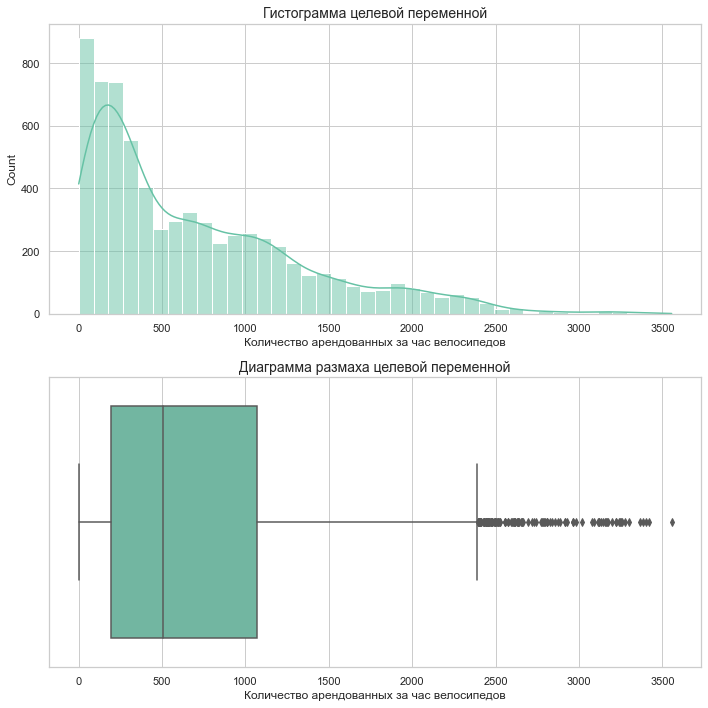

In [14]:
# гистограмма и диаграмма размаха таргета
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# гистограмма
sns.histplot(train[TARGET], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Гистограмма целевой переменной')
axes[0].set_xlabel('Количество арендованных за час велосипедов')

# диаграмма размаха
sns.boxplot(x=train[TARGET], ax=axes[1])
axes[1].set_title('Диаграмма размаха целевой переменной')
axes[1].set_xlabel('Количество арендованных за час велосипедов')

plt.tight_layout()
plt.show()

**Анализ признаков**

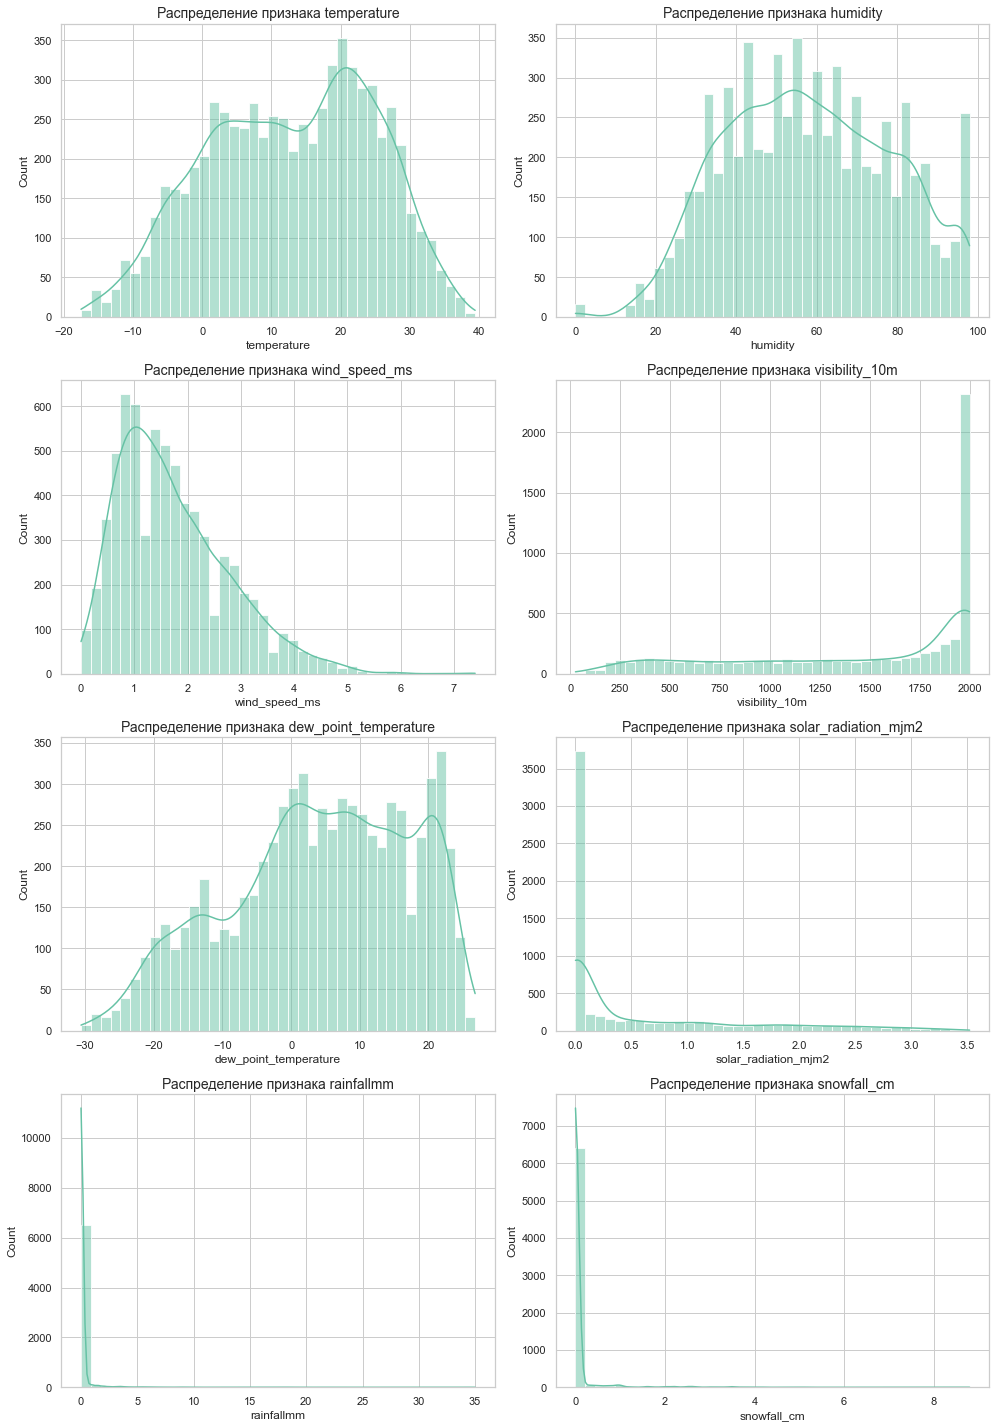

In [15]:
# числовые признаки
numeric_cols = train.select_dtypes(include=['number']).columns.drop(TARGET)

# количество строк в сетке
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / 2)

# сетка
fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 5))
axes = axes.flatten()

# построение гистрограммы
for i, col in enumerate(numeric_cols):
    sns.histplot(train[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение признака {col}')
    axes[i].set_xlabel(col)

# удаление пустых графиков
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Анализ корреляций**

Оценим корреляции числовых признаков с таргетом методом Спирмена, оценивающим не только линейные, но и монотонные зависимости.

Коэффициенты корреляции Спирмена признаков с таргетом:


temperature              0.567
dew_point_temperature    0.381
solar_radiation_mjm2     0.379
visibility_10m           0.174
wind_speed_ms            0.139
humidity                -0.212
snowfall_cm             -0.225
rainfallmm              -0.274
Name: rented_bike_count, dtype: float64

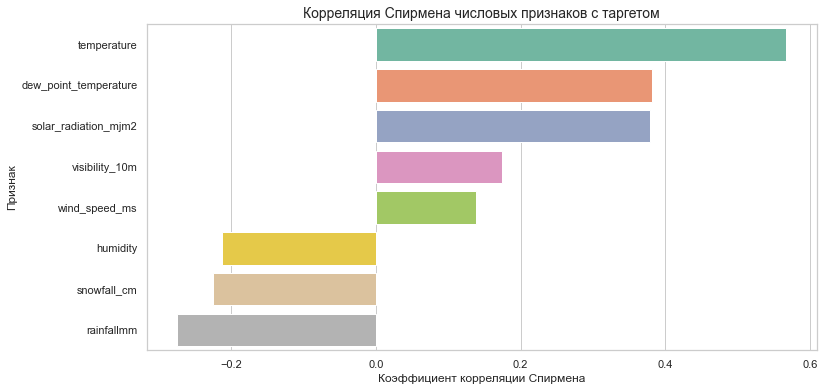

In [16]:
numeric_corr = train.select_dtypes(include=['number']).columns.drop(TARGET)
num_corr_matrix = train[list(numeric_corr) + [TARGET]].corr(method='spearman')[TARGET]
num_corr_matrix = (
    num_corr_matrix
    .drop(TARGET)
    .sort_values(ascending=False)
)

print('Коэффициенты корреляции Спирмена признаков с таргетом:')
display(num_corr_matrix.sort_values(ascending=False))

sns.barplot(
    x=num_corr_matrix.values,
    y=num_corr_matrix.index,
    orient='h'
)
plt.title('Корреляция Спирмена числовых признаков с таргетом')
plt.xlabel('Коэффициент корреляции Спирмена')
plt.ylabel('Признак')
plt.show()

Оценим корреляции всех призанков с таргетом с помощью коэффициента phi_k.

In [17]:
# явное указание непрерывных призанков
interval_cols = [
    'temperature', 
    'humidity', 
    'wind_speed_ms', 
    'visibility_10m', 
    'dew_point_temperature', 
    'solar_radiation_mjm2', 
    'rainfallmm', 
    'snowfall_cm', 
    'rented_bike_count'
]
phik_corr = (
    train
    .phik_matrix(interval_cols=interval_cols)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

print('Коэффициенты корреляции phi_k признаков с таргетом:')
display(phik_corr)

Коэффициенты корреляции phi_k признаков с таргетом:


temperature                0.603
time_period_night          0.509
seasons                    0.491
time_period_evening        0.490
dew_point_temperature      0.464
solar_radiation_mjm2       0.457
humidity                   0.309
functioning_day            0.288
time_period_late_evening   0.276
visibility_10m             0.241
wind_speed_ms              0.209
holiday                    0.127
snowfall_cm                0.117
time_period_morning        0.101
rainfallmm                 0.047
Name: rented_bike_count, dtype: float64

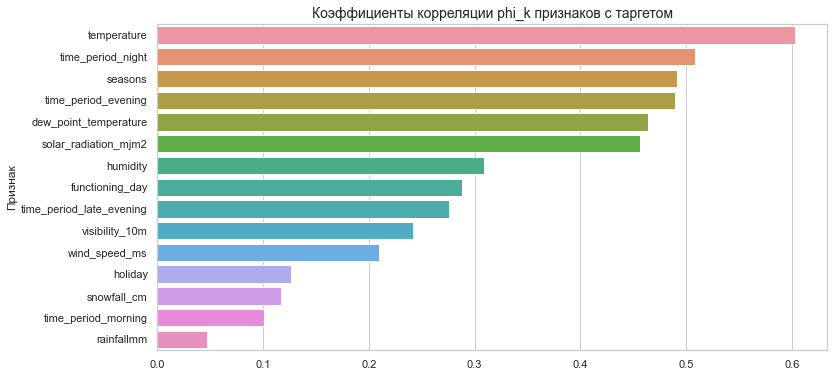

In [18]:
sns.barplot(
    x=phik_corr.values,
    y=phik_corr.index,
    orient='h'
)
plt.title('Коэффициенты корреляции phi_k признаков с таргетом')
plt.ylabel('Признак')
plt.show()

**Анализ целевой переменной в разрезе признаков**

Для анализа спроса в разрезе времени суток создадим на основе булевых столбцов `time_period_` единый категориальный столбец `time_period`.

In [19]:
time_columns = [
    'time_period_evening',
    'time_period_late_evening',
    'time_period_morning',
    'time_period_night'
]
        
# условия
condlist = [
    train['time_period_evening'] == True,
    train['time_period_late_evening'] == True,
    train['time_period_morning'] == True,
    train['time_period_night'] == True,
    train[time_columns].sum(axis=1) == 0
]
choicelist = [
    'evening',
    'late_evening',
    'morning',
    'night',
    'day'
]

# создание единого категориального признака
train['time_period'] = np.select(condlist, choicelist, 'unknown')
display(train['time_period'].value_counts())

night           1753
day             1742
late_evening    1173
morning         1172
evening         1168
Name: time_period, dtype: int64

Напишу в виде функции расчет среднего значения таргета в разрезе категориальных и булевых признаков.

In [20]:
non_num_cols = train.select_dtypes(exclude=['number']).columns.to_list()
non_num_cols = [x for x in non_num_cols if x not in [
    'time_period_evening',
    'time_period_late_evening',
    'time_period_morning',
    'time_period_night'
]]

In [21]:
def calculate_mean_target(data, column):
    """
    Считает среднее значение целевой переменной в разрезе признака column
    """
    grouped_data = (
        data.groupby(by=column, dropna=False)[TARGET]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    return grouped_data

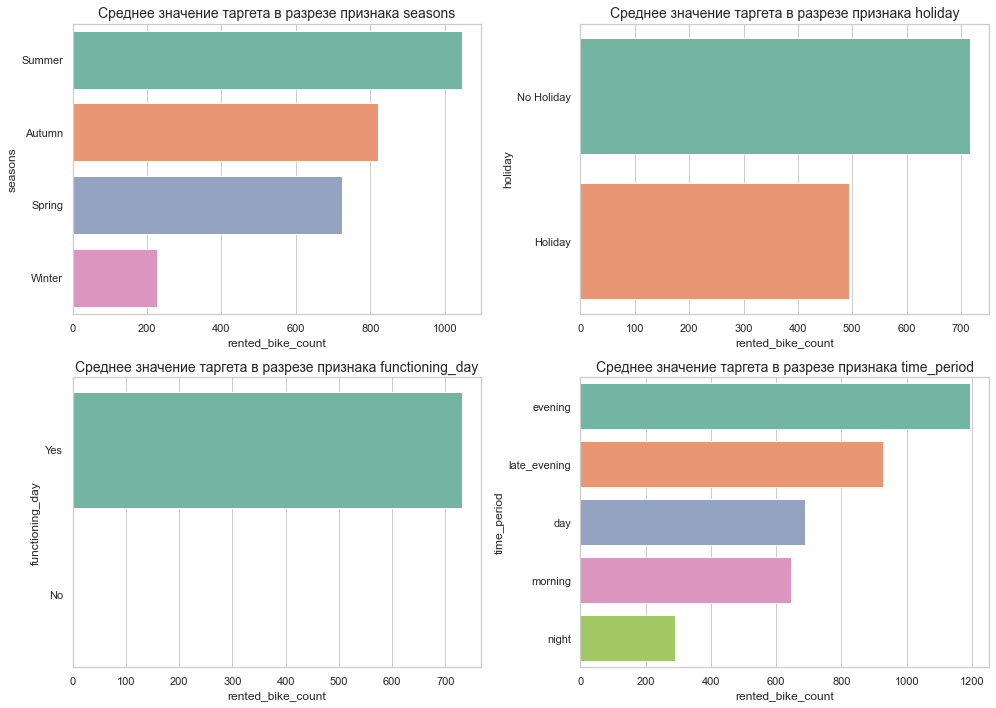

In [22]:
n_cols = len(non_num_cols)
n_rows = math.ceil(n_cols / 2)

fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 5))
axes = axes.flatten()
for i, col in enumerate(non_num_cols):
    data = calculate_mean_target(train, col)
    sns.barplot(data=data, x=TARGET, y=col, orient='h', ax=axes[i])
    axes[i].set_title(f"Среднее значение таргета в разрезе признака {col}")
    
for j in range(i+1, n_cols):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

Визуализируем сводную таблицу среднего спроса в разрезе сезона и времени суток:

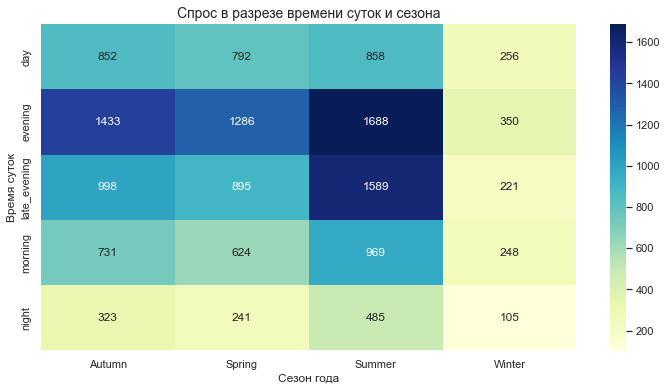

In [23]:
pivot_table = pd.pivot_table(
    data=train,
    values=TARGET,
    columns='seasons',
    index='time_period',
    aggfunc='mean'
)

sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Спрос в разрезе времени суток и сезона')
plt.xlabel('Сезон года')
plt.ylabel('Время суток')
plt.show()

**Вывод по EDA**

Распределение целевой переменной заметно скошено вправо: много часов с низким и средним спросом, но есть часы с очень высокой арендой. Значит крупные ошибки на пиковых часах будут особенно важны для RMSE.

На спрос заметно влияют температура, время суток, сезонность, рабочее состояние проката, осадки, влажность и солнечная радиация. Эти признаки хорошо согласуются с бизнес-гипотезой BikeSouth: спрос зависит не от одного фактора, а от контекста погоды и времени.

## Создание кастомного трансформера <a id="5"></a>

In [24]:
class BikeFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, comfort_temp=24, extreme_humidity=70):
        self.comfort_temp = comfort_temp
        self.extreme_humidity = extreme_humidity
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X['holiday']= X['holiday'].replace(
            {
                'Holiday': 1,
                'No Holiday': 0
            }
        ).astype(float)
        
        X['functioning_day']= X['functioning_day'].replace(
            {
                'Yes': 1,
                'No': 0
            }
        ).astype(float)
        
        time_columns = [
            'time_period_evening',
            'time_period_late_evening',
            'time_period_morning',
            'time_period_night'
        ]
        condlist = [
            X['time_period_evening'] == True,
            X['time_period_late_evening'] == True,
            X['time_period_morning'] == True,
            X['time_period_night'] == True,
            X[time_columns].sum(axis=1) == 0
        ]
        choicelist = [
            'evening',
            'late_evening',
            'morning',
            'night',
            'day'
        ] 
        X['time_period'] = np.select(condlist, choicelist, 'unknown')
        
        X['temp_zone'] = pd.cut(
            x=X['temperature'],
            bins=[-np.inf, 5, 15, 27, +np.inf],
            labels=['cold', 'cool', 'comfortable', 'hot']
        ).astype('object').fillna('unknown')
        
        X['comfort_distance'] = (X['temperature'] - self.comfort_temp).abs()
        
        X['dew_point_distance'] = X['temperature'] - X['dew_point_temperature']
        
        X['extreme_humidity_flag'] = (X['humidity'] > self.extreme_humidity).astype(float)
        
        return X.drop(columns=time_columns)

Булевы маски приводим к float, чтобы с ними мог работать SimpleImputer, который, как оказывается не может работать с bool.

---

In [25]:
train_processed = BikeFeatureEngineer().fit_transform(train)

Проанализируем корреляции phi_k новых признаков с таргетом

In [26]:
# анализ корреляций
interval_cols = [
    'temperature', 
    'humidity', 
    'wind_speed_ms', 
    'visibility_10m', 
    'dew_point_temperature', 
    'solar_radiation_mjm2', 
    'rainfallmm', 
    'snowfall_cm', 
    'rented_bike_count', 
    'comfort_distance', 
    'dew_point_distance'
]

phik_corr_transformed = (
    train_processed
    .phik_matrix(interval_cols=interval_cols)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

print('Коэффициенты корреляции phi_k признаков с таргетом:')
display(phik_corr_transformed)

Коэффициенты корреляции phi_k признаков с таргетом:


temperature             0.603
time_period             0.592
comfort_distance        0.590
temp_zone               0.543
seasons                 0.491
dew_point_temperature   0.464
solar_radiation_mjm2    0.457
dew_point_distance      0.324
humidity                0.309
functioning_day         0.288
extreme_humidity_flag   0.251
visibility_10m          0.241
wind_speed_ms           0.209
holiday                 0.127
snowfall_cm             0.117
rainfallmm              0.047
Name: rented_bike_count, dtype: float64

Отметим, что объединенный признак `time_period` имеет более высокую корреляцию, чем отдельные бинарные флаги `time_period_`. `temp_zone`, `comfort_distance` тоже высоко коррелируют с таргетом.

## Подготовка пайплайнов <a id="6"></a>

Подготовим пайплайны для обработки всех признаков с учетом того, что они пройдут сначала через кастомный трансформер.

In [28]:
# бинарные признаки
binary_features = [
    'holiday',
    'functioning_day',
    'extreme_humidity_flag',
]

# числовые непрерывные признаки
numerical_features = [
    'temperature',
    'humidity',
    'wind_speed_ms',
    'visibility_10m',
    'dew_point_temperature',
    'solar_radiation_mjm2',
    'rainfallmm',
    'snowfall_cm',
    'comfort_distance',
    'dew_point_distance',
]

# категориальные признаки для OneHot кодирования
onehot_features = [
    'seasons',
    'time_period',
    'temp_zone'
]

In [29]:
# pipeline для бинарных признаков
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# pipeline для числовых непрерывных признаков
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# pipeline для категориальных признаков
onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first', # избавляемся от dummy-ловушки
        handle_unknown='ignore',
        sparse_output=False
    ))
])


# объединение в трансформер
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('onehot', onehot_pipeline, onehot_features),
        ('bin', binary_pipeline, binary_features),
    ],
    remainder='drop'
).set_output(transform='pandas')

## Обучение базовых моделей <a id="7"></a>

Алгоритмы kNN и DecisionTreeRegressor обучим на базовом наборе параметров для фиксации "точки отсчета" качества моделей.

In [30]:
# scoring-метрики
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

In [31]:
# настройка разбиения на фолды
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

In [32]:
# функция для расчета метрик на кросс-валидации
def calc_cv_metrics(results):
    """
    Считает метрики на тестовых фолдах кросс-валидации
    """
    res_dict = {
        'RMSE': -results['test_rmse'].mean(),
        'RMSE_std': results['test_rmse'].std(),
        'MAE': -results['test_mae'].mean(),
        'R2': results['test_r2'].mean()
    }
    return res_dict

**Модель kNN**

In [33]:
knn_base_model = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance',
    p=2
)

knn_base_pipeline = Pipeline(steps=[
    ('feature_engineer', BikeFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', knn_base_model)
])

knn_base_res = cross_validate(
    estimator=knn_base_pipeline,
    X=X_train,
    y=y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

In [34]:
print('Результаты базовой содели kNN')
display(pd.Series(calc_cv_metrics(knn_base_res)))

Результаты базовой содели kNN


RMSE       330.263
RMSE_std     7.522
MAE        220.154
R2           0.738
dtype: float64

**Модель DecisionTree**

In [35]:
dtree_base_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=RANDOM_STATE
)

dtree_base_pipeline = Pipeline(steps=[
    ('feature_engineer', BikeFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', dtree_base_model)
])

dtree_base_res = cross_validate(
    estimator=dtree_base_pipeline,
    X=X_train,
    y=y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

In [36]:
print('Результаты базовой модели DecisionTree')
display(pd.Series(calc_cv_metrics(dtree_base_res)))

Результаты базовой модели DecisionTree


RMSE       324.236
RMSE_std    10.234
MAE        213.046
R2           0.748
dtype: float64

## Подбор гиперпараметров через Optuna <a id="8"></a>

In [37]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 30
display(cv)

KFold(n_splits=5, random_state=42, shuffle=True)

In [38]:
# функция objective для knn
def knn_objective(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 80),
        "weights": trial.suggest_categorical("weights", ['uniform', 'distance']),
        "p": trial.suggest_int('p', 1, 2)
    }
    
    model = KNeighborsRegressor(**params)
    pipeline = Pipeline(steps=[
        ('feature_engineer', BikeFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scorer = 'neg_root_mean_squared_error'
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scorer
    )
    
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

knn_study = optuna.create_study(direction="minimize", sampler=sampler)

knn_study.optimize(knn_objective, n_trials=N_TRIALS, show_progress_bar=False)

print('Лучшее значение RMSE для kNN:', round(knn_study.best_value, 3))
print('Лучшие параметры kNN:')
print(knn_study.best_params)

Лучшее значение RMSE для kNN: 321.207
Лучшие параметры kNN:
{'n_neighbors': 9, 'weights': 'distance', 'p': 1}


In [39]:
# функция objective для DecisionTree
def dtree_objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 40)
    }
    
    model = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    pipeline = Pipeline(steps=[
        ('feature_engineer', BikeFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scorer = 'neg_root_mean_squared_error'
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scorer
    )
    
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

dtree_study = optuna.create_study(direction="minimize", sampler=sampler)

dtree_study.optimize(dtree_objective, n_trials=N_TRIALS, show_progress_bar=False)

print('Лучшее значение RMSE для DecisionTree:', round(dtree_study.best_value, 3))
print('Лучшие параметры DecisionTree:')
print(dtree_study.best_params)

Лучшее значение RMSE для DecisionTree: 315.897
Лучшие параметры DecisionTree:
{'max_depth': 15, 'min_samples_split': 63, 'min_samples_leaf': 19}


## Сравнение моделей и финальная проверка <a id="9"></a>

Оценим лучшие версии kNN и дерева решений на кросс-валидации по трём метрикам: RMSE, MAE и $R^2$.

In [40]:
best_knn_pipeline = Pipeline(steps=[
    ('feature_engineer', BikeFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(**knn_study.best_params))
])

best_knn_res = cross_validate(
    estimator=best_knn_pipeline,
    X=X_train,
    y=y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

best_knn_metrics = calc_cv_metrics(best_knn_res)

In [41]:
best_dtree_pipeline = Pipeline(steps=[
    ('feature_engineer', BikeFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, **dtree_study.best_params))
])

best_dtree_res = cross_validate(
    estimator=best_dtree_pipeline,
    X=X_train,
    y=y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

best_dtree_metrics = calc_cv_metrics(best_dtree_res)

In [42]:
best_metrics = pd.DataFrame([best_knn_metrics, best_dtree_metrics], index=['kNN', 'DecisionTree'])
print('Таблица с метриками лучших моделей')
display(best_metrics)

Таблица с метриками лучших моделей


,RMSE,RMSE_std,MAE,R2
kNN,321.207,7.393,214.275,0.753
DecisionTree,315.897,9.311,211.279,0.761


Для большей наглядности выведем полученные на тестовых фолдах метрики:

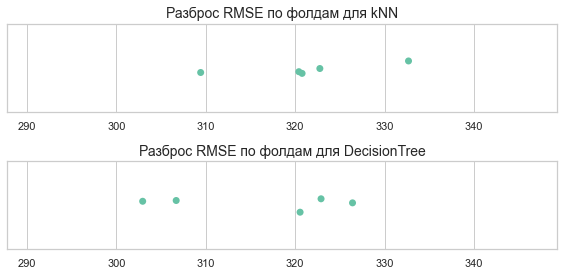

In [43]:
max_metric = -min(min(best_knn_res['test_rmse']), min(best_dtree_res['test_rmse']))
min_metric = -max(max(best_knn_res['test_rmse']), max(best_dtree_res['test_rmse']))

fig, axes = plt.subplots(2, 1, figsize=(8, 4))
sns.stripplot(x=-best_knn_res['test_rmse'], ax=axes[0], size=7)
sns.stripplot(x=-best_dtree_res['test_rmse'], ax=axes[1], size=7)
for i, title in enumerate(['kNN', 'DecisionTree']):
    axes[i].set_title(f'Разброс RMSE по фолдам для {title}')
    axes[i].set_xlim(0.95*min_metric, 1.05*max_metric)
plt.tight_layout()
plt.show()

---
Метрики по фолдам DecisionTree разбросаны действительно шире, о чем и говорит значение стандартного отклонения. kNN выглядит "кучнее", но есть пара нестабильных фолдов.  
Лучшей моделью по среднему значению целевой метрики RMSE является дерево решений, несмотря на то, что она менее стабильна по метрике RMSE. По метрикам MAE и $R^2$ она показала себя тоже лучше.

---
По целевой метрике после оптимизации лучшей моделью признана DecisionTree. Получим предсказания на тесте.

In [44]:
best_dtree_pipeline.fit(X_train, y_train)

y_dtree_pred = best_dtree_pipeline.predict(X_test)

final_comparison = pd.DataFrame([
    {'model': 'Baseline Linear Regression', **baseline_metrics.loc['test'].to_dict()},
    {'model': 'Best Decision Tree', **regression_metrics(y_test, y_dtree_pred)}
])

In [45]:
print('Сравнение метрик на тесте для baseline модели и для дерева решений')
display(final_comparison)

Сравнение метрик на тесте для baseline модели и для дерева решений


,model,RMSE,MAE,R2
0,Baseline Linear Regression,411.454,312.531,0.586
1,Best Decision Tree,311.735,206.080,0.763


---
**Вывод по моделям**

По кросс-валидации лучшей моделью стала **Decision Tree**: её RMSE на тренировочных данных около **316**, тогда как у дерева решений RMSE около **321**. На финальной тестовой выборке Decision Tree тоже лучше baseline: RMSE снизилась примерно на 25% с **411** до **312**, MAE примерно с **313** до **206**, а $R^2$ выросла примерно с **0.59** до **0.76**.

Дереву решений, ровно как и модели k ближайших соседей, удалось уловить нелинейный характер зависимости таргета от признаков, что заметно по улучшившимся метрикам.

## Оценка важности признаков <a id="10"></a>

Лучшей после оптимизации средствами Optuna оказалась модель Decision Tree. Она поддерживает вывод важности признаков.

Топ-10 по важности признаков


,feature,importance
0,num__temperature,0.315
16,onehot__time_period_night,0.173
9,num__dew_point_distance,0.124
21,bin__functioning_day,0.110
13,onehot__time_period_evening,0.086
14,onehot__time_period_late_evening,0.046
8,num__comfort_distance,0.036
12,onehot__seasons_Winter,0.035
5,num__solar_radiation_mjm2,0.031
10,onehot__seasons_Spring,0.012


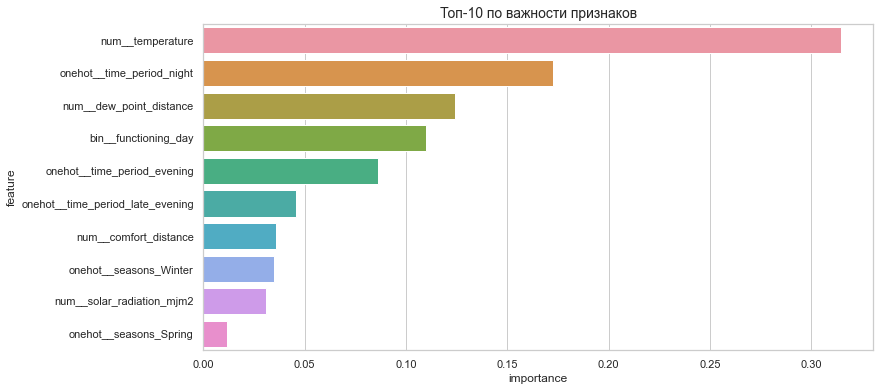

In [46]:
preprocessor = best_dtree_pipeline.named_steps['preprocessor']
model = best_dtree_pipeline.named_steps['model']

# датафрейм с признаками и их важностью
feature_importance = pd.DataFrame(
    {
        'feature': preprocessor.get_feature_names_out(),
        'importance': model.feature_importances_,
    }
).sort_values(by='importance', ascending=False)

print('Топ-10 по важности признаков')
display(feature_importance.head(10))

sns.barplot(x=feature_importance.head(10)['importance'], y=feature_importance.head(10)['feature'], orient='h')
plt.title('Топ-10 по важности признаков')
plt.show()

---
**Вывод по важности признаков**

Самыми важными для дерева оказались температура, время суток, тип погоды, сезонность и признаки, связанные с ощущением погоды: разница между температурой и точкой росы, расстояние до комфортной температуры, солнечная радиация. Это подтверждает гипотезу из постановки задачи: BikeSouth важны не только отдельные погодные показатели, но и их сочетания. Особенно заметен вклад ночного и вечернего времени.

## Сохранение модели<a id="11"></a>

Для повторного использования в отдельном приложении класс `BikeFeatureEngineer` нужно перенести в Python-модуль и импортировать перед загрузкой joblib-файла. Отдельный модуль доступен в репозитории по ссылке 

In [47]:
# сохранение кастомного трансформера
joblib.dump(BikeFeatureEngineer, 'BikeFeatureEngineer.joblib')

# сохранение препроцессора
joblib.dump(preprocessor, 'preprocessor.joblib')

# сохранение лучшей модели
joblib.dump(best_dtree_pipeline, 'best_dtree_pipeline.joblib')

['best_dtree_pipeline.joblib']

Проверим работоспособность сохраненной модели:

In [48]:
# проверка загрузкой
loaded_pipeline = joblib.load('best_dtree_pipeline.joblib')

# получение предсказаний
y_load = loaded_pipeline.predict(X_test)
loaded_rmse = root_mean_squared_error(y_test, y_load)

# сравнение
print(f"RMSE загруженной модели: {round(loaded_rmse, 4)}")
print(f"RMSE исходной модели: {round(final_comparison.iloc[1]['RMSE'], 4)}")

RMSE загруженной модели: 311.7346
RMSE исходной модели: 311.7346


Метрика совпала. Сохраненные артефакты корректны.

## Выводы<a id="12"></a>

1. **Baseline-модель недостаточно точна.** Линейная регрессия даёт RMSE около 411 на тестовой выборке и объясняет примерно 59% вариации спроса. При этом линейная форма зависимости плохо подходит для описания погоды, т .к. одна и та же температура может означать разный спрос в зависимости от дождя, солнца, влажности и времени суток.

2. **Лучшая модель - DecisionTreeRegressor.** После подбора гиперпараметров через Optuna дерево решений показало лучший результат на 5-fold кросс-валидации и подтвердило качество на финальном тесте: RMSE около 312, MAE около 206, R² около 0.76. По сравнению с baseline RMSE снизилась примерно на 25%.

3. **Ключевые факторы спроса:** температура, время суток, тип погоды, сезон, рабочее состояние проката, солнечная радиация и признаки, описывающие комфортность погоды.

4. **Рекомендации BikeSouth:**
   * использовать DecisionTree-пайплайн как новую модель прогноза почасового спроса;
   * сохранять в будущих данных точный час или дату, если они доступны, тк это позволит добавить календарные признаки, день недели и праздничные периоды;
   * можно отдельно мониторить (более подробно) пиковые часы.

Итог: новая нелинейная модель заметно улучшает прогноз относительно линейного baseline и лучше соответствует бизнес-задаче BikeSouth.